# 08 — Checklist di validazione sul Caso C: stadio 2 su $\hat\Omega_0$ (v0.11)

Il notebook 07 (v0.10) lasciava due punti aperti **(d)**:

1. a N = 50 lo stadio 1 iterato peggiorava $\log\sigma_E$: bias −0.27, coverage al 90% pari a 0.82;
2. la coverage 68% di $\mu_E$ a N = 1000 valeva 0.57 con M = 40.

Il test diretto (report §10) ha confrontato, sugli stessi dataset, lo stadio 1 a prior largo e quello
iterato, con N = 50 e M = 200 e con N = 1000 e M = 100. Ne è venuta la **correzione della v0.11**:

* $\hat\Omega_0$: stadio 1 a prior largo su $E_n$;
* stadio 2 su $\hat\Omega_0$, da cui $(\hat\mu_E, \hat\sigma_E)$, **che sono le stime riportate**;
* stadio 1 iterato con prior plug-in $N(\hat\mu_E, \hat\sigma_E)$, da cui $\hat\Omega_n$, **usato solo per la direzione**.

Stesso setup, seed e M del notebook 07. Il run usa lo stesso comando del notebook 07 (3 processi); il
risultato è in `outputs/caso_C_checklist_results.pkl`. La v0.10 è stata salvata a parte, in
`outputs/caso_C_checklist_results_v0.10.pkl`.

**Etichette.** (a) fatto consolidato · (b) stima toy con assunzioni esplicite · (c) verificato
con Monte Carlo · (d) ipotesi da testare.

In [1]:
import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "scripts"))
from caso_C_checklist import collect, rms          # stessa riduzione dei dati dello script
from riptide_toy import validate

plt.rcParams["figure.dpi"] = 110
RUNS = {}
for tag, name in [("v0.10", "caso_C_checklist_results_v0.10.pkl"), ("v0.11", "caso_C_checklist_results.pkl")]:
    with open(Path("..") / "outputs" / name, "rb") as f:
        RUNS[tag] = pickle.load(f)
LEVELS, N_ROB = RUNS["v0.11"]["LEVELS"], RUNS["v0.11"]["N_ROBUSTNESS"]
N_VALUES = sorted(n for n, _ in RUNS["v0.11"]["N_M"])
T = {tag: {n: collect(r["results"], n) for n in N_VALUES} for tag, r in RUNS.items()}
print("esperimenti per N:", {n: len(T["v0.11"][n]["mu_true"]) for n in N_VALUES})


def summary(t: dict) -> dict:
    """Bias, pull e coverage di un blocco di esperimenti a N fissato."""
    m = len(t["mu_true"])
    mu_res = t["mu_mean"] - t["mu_true"]
    ls_res = t["ls_median"] - np.log(t["sigma_true"])
    return {
        "m": m,
        "mu_res": mu_res, "ls_res": ls_res,
        "bias_mu": (mu_res.mean(), mu_res.std() / np.sqrt(m)),
        "bias_ls": (ls_res.mean(), ls_res.std() / np.sqrt(m)),
        "pull_mu": (t["mu_mean"] - t["mu_true"]) / t["mu_std"],
        "pull_ls": (t["ls_mean"] - np.log(t["sigma_true"])) / t["ls_std"],
        "pull_om": validate.angular_pull(t["omega_error"], t["omega_sigma"]),
        "cov_mu": validate.coverage_curve(t["mu_true"], t["mu_int"], LEVELS)[1],
        "cov_ls": validate.coverage_curve(np.log(t["sigma_true"]), t["ls_int"], LEVELS)[1],
        "cov_om": t["omega_covered"].mean(axis=0),
    }


S = {tag: {n: summary(T[tag][n]) for n in N_VALUES} for tag in RUNS}
fmt = lambda c: " / ".join(f"{v:.2f}" for v in c)

esperimenti per N: {50: 200, 150: 200, 300: 100, 1000: 40}


## 0. Controllo di coerenza

La correzione cambia soltanto il valore di $\hat\Omega$ su cui è condizionato lo stadio 2. La
direzione riportata viene dallo stadio 1 iterato, il cui prior plug-in usa ancora lo stadio 2 su
$\hat\Omega_0$. Quindi **i risultati su $\Omega_n$ devono essere identici** a quelli della v0.10,
esperimento per esperimento.

In [2]:
for n in N_VALUES:
    a, b = T["v0.10"][n], T["v0.11"][n]
    same = all(np.array_equal(a[k], b[k]) for k in ("mu_true", "sigma_true", "omega_error", "omega_sigma", "omega_covered"))
    print(f"N={n:5d}: verità e Omega identiche alla v0.10: {same}")

N=   50: verità e Omega identiche alla v0.10: True
N=  150: verità e Omega identiche alla v0.10: True
N=  300: verità e Omega identiche alla v0.10: True
N= 1000: verità e Omega identiche alla v0.10: True


## 1. Bias, pull e coverage: v0.10 contro v0.11

    N        |      bias mu [MeV] |    bias log sig |     pull mu |     pull ls |  cov mu 68/90/95 |      cov log sig |        cov Omega
   50 v0.10  | +0.0015 +- 0.0057 | -0.271 +- 0.037 | -0.02/1.01 | -0.37/0.93 | 0.65 / 0.89 / 0.95 | 0.61 / 0.82 / 0.91 | 0.70 / 0.86 / 0.93
   50 v0.11  | +0.0023 +- 0.0057 | -0.154 +- 0.033 | -0.01/0.98 | -0.11/0.96 | 0.68 / 0.91 / 0.96 | 0.67 / 0.89 / 0.93 | 0.70 / 0.86 / 0.93
             errore binomiale 68/90/95 con M=200: 0.033 / 0.021 / 0.015
  150 v0.10  | -0.0001 +- 0.0036 | -0.083 +- 0.020 | +0.01/0.97 | -0.19/1.01 | 0.70 / 0.92 / 0.95 | 0.60 / 0.87 / 0.94 | 0.65 / 0.88 / 0.93
  150 v0.11  | +0.0007 +- 0.0036 | -0.055 +- 0.019 | +0.03/0.98 | -0.02/1.05 | 0.69 / 0.92 / 0.95 | 0.60 / 0.87 / 0.94 | 0.65 / 0.88 / 0.93
             errore binomiale 68/90/95 con M=200: 0.033 / 0.021 / 0.015
  300 v0.10  | -0.0013 +- 0.0039 | -0.031 +- 0.017 | -0.04/1.14 | -0.13/1.07 | 0.66 / 0.87 / 0.91 | 0.64 / 0.87 / 0.92 | 0.66 / 0.91 / 0.95
  300 v0.11  | -0.0

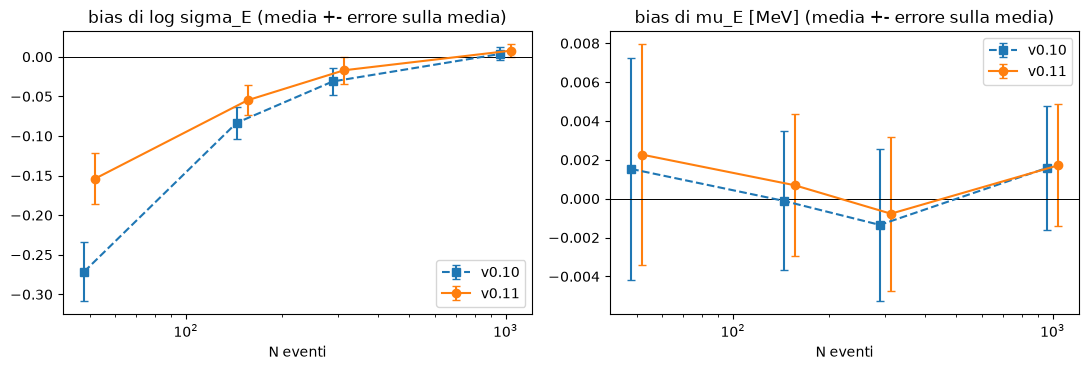

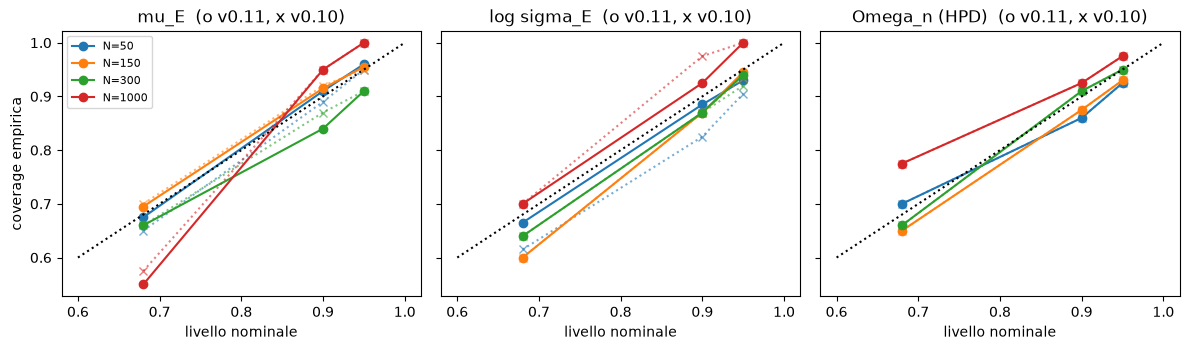

In [3]:
print(f"{'N':>5} {'':6} | {'bias mu [MeV]':>18} | {'bias log sig':>15} | {'pull mu':>11} | {'pull ls':>11} |"
      f" {'cov mu 68/90/95':>16} | {'cov log sig':>16} | {'cov Omega':>16}")
for n in N_VALUES:
    for tag in RUNS:
        s = S[tag][n]
        print(f"{n:5d} {tag:6} | {s['bias_mu'][0]:+.4f} +- {s['bias_mu'][1]:.4f} |"
              f" {s['bias_ls'][0]:+.3f} +- {s['bias_ls'][1]:.3f} |"
              f" {s['pull_mu'].mean():+.2f}/{s['pull_mu'].std():.2f} | {s['pull_ls'].mean():+.2f}/{s['pull_ls'].std():.2f} |"
              f" {fmt(s['cov_mu']):>16} | {fmt(s['cov_ls']):>16} | {fmt(s['cov_om']):>16}")
    m = S["v0.11"][n]["m"]
    print(f"{'':12} errore binomiale 68/90/95 con M={m}: " + " / ".join(f"{np.sqrt(l * (1 - l) / m):.3f}" for l in LEVELS))
print("\npull Omega rms (v0.11):", {n: round(rms(S["v0.11"][n]["pull_om"]), 2) for n in N_VALUES})

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
x = np.array(N_VALUES)
for ax, key, name in zip(axes, ["bias_ls", "bias_mu"], ["bias di log sigma_E", "bias di mu_E [MeV]"]):
    for tag, shift, style in [("v0.10", 0.96, "s--"), ("v0.11", 1.04, "o-")]:
        b = np.array([S[tag][n][key] for n in N_VALUES])
        ax.errorbar(x * shift, b[:, 0], b[:, 1], fmt=style, capsize=3, label=tag)
    ax.axhline(0, color="k", lw=0.7)
    ax.set_xscale("log")
    ax.set_xlabel("N eventi")
    ax.set_title(name + " (media +- errore sulla media)")
    ax.legend()
fig.tight_layout()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, key, name in zip(axes, ["cov_mu", "cov_ls", "cov_om"], ["mu_E", "log sigma_E", "Omega_n (HPD)"]):
    for i, n in enumerate(N_VALUES):
        ax.plot(LEVELS, S["v0.11"][n][key], "o-", color=f"C{i}", label=f"N={n}")
        ax.plot(LEVELS, S["v0.10"][n][key], "x:", color=f"C{i}", alpha=0.6)
    ax.plot([0.6, 1.0], [0.6, 1.0], "k:")
    ax.set_title(name + "  (o v0.11, x v0.10)")
    ax.set_xlabel("livello nominale")
axes[0].set_ylabel("coverage empirica")
axes[0].legend(fontsize=8)
fig.tight_layout()

* **$\Omega_n$**: identica alla v0.10 (controllo 0), quindi resta calibrata con pull rms 1.08,
  1.05, 1.00, 0.89.
* **$\log\sigma_E$ a N = 50**: il bias torna da −0.27 a **−0.15 ± 0.03**, come nella v0.9, e la
  coverage da 0.61 / 0.82 / 0.91 a **0.67 / 0.89 / 0.93**, entro gli errori binomiali. La
  regressione della v0.10 è quindi chiusa **(c)**. A N = 150 e 300 il bias scende a −0.055 e −0.017.
* **$\mu_E$**: invariata entro gli errori. A N = 300 la coverage al 90% vale 0.84, cioè −2
  errori binomiali, contro 0.87 della v0.10; la larghezza del pull resta 1.14 in entrambe le versioni.
* **Coverage 68% di $\mu_E$ a N = 1000**: 0.55 con M = 40, 22/40 esperimenti. Il test con
  **M = 100** sugli stessi seed più 60 nuovi (report §10) dà **0.65 / 0.95 / 0.99** con errore
  ±0.047 al 68%, e pull 0.01 / 0.95. Nei 40 esperimenti della checklist la coverage vale
  0.55, nei 60 nuovi 0.72. È una **fluttuazione statistica di M = 40 (c)**, non un difetto.

**Test diretto a N = 50, M = 200** (report §10), sugli stessi dataset:

| | stadio 1 a prior largo | stadio 1 iterato |
|---|---|---|
| $\Omega$: errore rms / pull rms | 3.05° / 0.79 | **1.96° / 1.08** |
| $\Omega$: coverage 68/90/95 | 0.84 / 0.965 / 0.995 | **0.70 / 0.86 / 0.925** |
| $\log\sigma_E$: bias | **−0.154 ± 0.033** | −0.271 ± 0.037 |
| $\log\sigma_E$: coverage 68/90/95 | **0.665 / 0.885 / 0.93** | 0.615 / 0.825 / 0.905 |

La v0.11 prende $\Omega_n$ dalla colonna iterata e $(\mu_E, \sigma_E)$ da quella a prior largo.
Meccanismo, ipotesi **(d)**: il prior plug-in $N(\hat\mu_E, \hat\sigma_E)$, con $\hat\sigma_E$ già
sottostimato, sceglie una direzione che si adatta a uno spettro stretto. Lo stadio 2 condizionato su
quella direzione rinforza la sottostima.

## 2. Risoluzione e contrazione (v0.11)

In [4]:
curves = {
    "mu": np.array([rms(S["v0.11"][n]["mu_res"]) for n in N_VALUES]),
    "log sigma": np.array([rms(S["v0.11"][n]["ls_res"]) for n in N_VALUES]),
    "Omega": np.array([rms(T["v0.11"][n]["omega_error"]) for n in N_VALUES]),
}
for n in N_VALUES:
    t, s = T["v0.11"][n], S["v0.11"][n]
    print(f"N={n:5d}: mu rms {rms(s['mu_res']):.4f} / dich. {t['mu_std'].mean():.4f} |"
          f" log sig rms {rms(s['ls_res']):.3f} / dich. {t['ls_std'].mean():.3f}")
for name, c in curves.items():
    slope = np.polyfit(np.log(N_VALUES), np.log(c), 1)[0]
    print(f"{name:10s} pendenza {slope:+.3f}  rms*sqrt(N) = {np.round(c * np.sqrt(N_VALUES), 3)}")

N=   50: mu rms 0.0805 / dich. 0.0880 | log sig rms 0.485 / dich. 0.416
N=  150: mu rms 0.0516 / dich. 0.0509 | log sig rms 0.272 / dich. 0.190
N=  300: mu rms 0.0396 / dich. 0.0351 | log sig rms 0.173 / dich. 0.111
N= 1000: mu rms 0.0200 / dich. 0.0193 | log sig rms 0.053 / dich. 0.058
mu         pendenza -0.462  rms*sqrt(N) = [0.569 0.632 0.686 0.631]
log sigma  pendenza -0.739  rms*sqrt(N) = [3.43  3.33  2.991 1.669]
Omega      pendenza -0.559  rms*sqrt(N) = [0.242 0.238 0.227 0.204]


## 3. Robustezza al prior (N = 150, v0.11)

In [5]:
t_log = collect(RUNS["v0.11"]["results"], N_ROB, "logU")
t_lin = collect(RUNS["v0.11"]["results"], N_ROB, "U")
d_mu = (t_lin["mu_mean"] - t_log["mu_mean"]) / t_log["mu_std"]
d_ls = (t_lin["ls_median"] - t_log["ls_median"]) / t_log["ls_std"]
_, cov_lin = validate.coverage_curve(np.log(t_lin["sigma_true"]), t_lin["ls_int"], LEVELS)
print(f"mu: medio {d_mu.mean():+.3f}, max |.| {np.abs(d_mu).max():.3f} |"
      f" log sigma: medio {d_ls.mean():+.3f}, max |.| {np.abs(d_ls).max():.3f} |"
      f" coverage log sigma con prior U: {fmt(cov_lin)}")

mu: medio -0.010, max |.| 0.152 | log sigma: medio +0.156, max |.| 0.743 | coverage log sigma con prior U: 0.58 / 0.88 / 0.96


## Esito

* Risoluzione, contrazione e robustezza al prior sono invariate rispetto alla v0.10: $\mu_E$ ha
  pendenza −0.46 e rms·$\sqrt N$ ≈ 0.6 senza plateau; $\Omega_n$ ha pendenza −0.56.
* **Chiuso (c):** regressione di $\log\sigma_E$ a N = 50; coverage di $\mu_E$ a N = 1000.

| parametro | v0.10 | v0.11 |
|---|---|---|
| $\Omega_n$ | calibrata a N ≥ 150; a N = 50 lievemente sovra-confidente al 90–95% | invariata |
| $\mu_E$ | calibrata; coverage 68% a N = 1000 dubbia | calibrata; il dubbio a N = 1000 era una fluttuazione (M = 100: 0.65) |
| $\sigma_E$ | a N = 50 bias −0.27, coverage 90% = 0.82 | a N = 50 bias −0.15, coverage 0.67 / 0.89 / 0.93 |

**Punti aperti (d)**

1. **Bias residuo di $\log\sigma_E$ a N piccolo**: −0.15 a N = 50, −0.055 a N = 150, presente già
   nella v0.9. Ipotesi: lo stadio 2 tratta $\hat\Omega_0$ come esatta e non propaga l'incertezza della
   direzione, circa 3° a N = 50. Rimedio possibile: marginalizzare lo stadio 2 su alcuni pixel della
   calotta, pesati con la posterior di $\Omega$.
2. **Rms di $\log\sigma_E$ maggiore della σ dichiarata a N = 150–300** (0.27 contro 0.19 e 0.17
   contro 0.11), anche se pull e coverage sono nominali; già presente nella v0.9. Probabile coda
   della distribuzione, non studiata.
3. **Coerenza**: $\hat\Omega_n$ e $(\hat\mu_E, \hat\sigma_E)$ non vengono più da un'unica stima
   congiunta. Va dichiarato quando si riportano insieme.